# Introduction to PyTorch

PyTorch is an open-source deep learning framework developed by Meta (Facebook). It has become one of the most popular frameworks for research and production because of:

- **Dynamic computation graphs**: Build and modify your computation graph on the fly, making it intuitive and flexible for debugging.
- **Pythonic design**: Feels like writing normal Python with tensor operations.
- **Research to production**: The same code can scale from experiments to deployment.

In this notebook we will cover **Tensors**, **Autograd** (automatic differentiation), **Model building** with `torch.nn`, **Training loops**, and end with a **text classification** project that ties everything together.

## Prerequisites & Installation

Ensure you have Python 3.8+ and pip. Install PyTorch and the libraries we will use in this notebook.

In [1]:
# Install PyTorch with CUDA support (run this in terminal with your venv active)
# Your system: RTX 4050, driver supports CUDA 13.1. Use cu128 (PyTorch bundles CUDA; driver is backward-compatible).
#
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
# pip install matplotlib scikit-learn
#
# If cu128 fails, try: --index-url https://download.pytorch.org/whl/cu126

In [2]:
### CUDA Is a GPU Processing driver - that is developed by Nvidia - Windows PC - NVidia - Intel - AMD  - Ryzen 

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU


### Device: CPU vs GPU

PyTorch can run on CPU or GPU (CUDA). We typically move our model and data to the same device. Use `torch.device('cuda')` when a GPU is available, otherwise `'cpu'`. This will be used throughout the notebook.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Tensors

A **tensor** is a multi-dimensional array of numbers. You can think of it as a generalization:
- **0-D tensor**: scalar (single number)
- **1-D tensor**: vector
- **2-D tensor**: matrix
- **3-D and beyond**: higher-dimensional arrays (e.g., batches of images)

PyTorch tensors are similar to NumPy arrays but with two key additions: they can run on GPU, and they support **automatic differentiation** (which we will see in the Autograd section).

70B - When you train a model - you train weights - store wrights Matrix - number of elements in the matrix = number of paramer - 70B

In [5]:
# Creating tensors
# From a list
t1 = torch.tensor([1.0, 2.0, 3.0])
print("From list:", t1)

# Zeros and ones with a shape
t2 = torch.zeros(2, 3)
t3 = torch.ones(2, 3)
print("Zeros (2,3):\n", t2)
print("Ones (2,3):\n", t3)

# Random values in [0, 1)
t4 = torch.rand(2, 3)
print("Random (2,3):\n", t4)

# Arange: similar to range()
t5 = torch.arange(0, 10, 2)  # start, end (exclusive), step
print("Arange(0,10,2):", t5)

# Linspace: evenly spaced values
t6 = torch.linspace(0, 1, 5)  # start, end, num points
print("Linspace(0,1,5):", t6)

From list: tensor([1., 2., 3.])
Zeros (2,3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
Ones (2,3):
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
Random (2,3):
 tensor([[0.5199, 0.1948, 0.8040],
        [0.5881, 0.1290, 0.8489]])
Arange(0,10,2): tensor([0, 2, 4, 6, 8])
Linspace(0,1,5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [6]:
# Tensor attributes: shape, dtype, device
x = torch.rand(3, 4)

print("Shape:", x.shape)       # or x.size()
print("Number of dimensions:", x.dim())
print("Data type:", x.dtype)
print("Device:", x.device)
print("Number of elements:", x.numel())

Shape: torch.Size([3, 4])
Number of dimensions: 2
Data type: torch.float32
Device: cpu
Number of elements: 12


### Tensor Data Types

Tensors have a data type (`dtype`). Common ones: `float32`, `float64`, `int32`, `int64`, `bool`. You can cast with `.to(dtype)` or shorthand methods like `.float()`, `.long()`, `.bool()`.

# FLoat 32 Vs FLoat64

In [7]:
# Default: float32 for float, int64 for int
a = torch.tensor([1, 2, 3])
b = torch.tensor([1.0, 2.0, 3.0])
print("int tensor dtype:", a.dtype)
print("float tensor dtype:", b.dtype)

# Casting
a_float = a.float()   # or a.to(torch.float32)
b_int = b.long()      # or b.to(torch.int64)
print("a as float:", a_float, a_float.dtype)
print("b as long:", b_int, b_int.dtype)

# Create with specific dtype
c = torch.tensor([1, 2], dtype=torch.float64)
c.to(torch.float32)
print("Explicit float32:", c.dtype)

int tensor dtype: torch.int64
float tensor dtype: torch.float32
a as float: tensor([1., 2., 3.]) torch.float32
b as long: tensor([1, 2, 3]) torch.int64
Explicit float32: torch.float64


### Tensor Operations

Tensors support element-wise arithmetic and matrix operations. Use `@` for matrix multiplication (Python 3.5+).

In [8]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])
print("a + b:", a + b)
print("a * b:", a * b)

# Matrix multiplication: (2,3) @ (3,2) -> (2,2)
A = torch.rand(2, 3)
B = torch.rand(3, 2)
C = A @ B   # or torch.matmul(A, B)
print("A shape:", A.shape, "B shape:", B.shape, "A@B shape:", C.shape)

# Dot product for 1D tensors
v = torch.tensor([1.0, 2.0])
w = torch.tensor([3.0, 4.0])
print("dot(v,w):", torch.dot(v, w))

a + b: tensor([5., 7., 9.])
a * b: tensor([ 4., 10., 18.])
A shape: torch.Size([2, 3]) B shape: torch.Size([3, 2]) A@B shape: torch.Size([2, 2])
dot(v,w): tensor(11.)


In [9]:
# Reduction operations
x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
print("Sum (all):", x.sum())
print("Sum (dim=0, along columns):", x.sum(dim=0))
print("Sum (dim=1, along rows):", x.sum(dim=1))
print("Mean:", x.mean())
print("Max:", x.max(), "Min:", x.min())
print("Argmax (index of max):", x.argmax(), "Argmax dim=1:", x.argmax(dim=1))

Sum (all): tensor(21.)
Sum (dim=0, along columns): tensor([5., 7., 9.])
Sum (dim=1, along rows): tensor([ 6., 15.])
Mean: tensor(3.5000)
Max: tensor(6.) Min: tensor(1.)
Argmax (index of max): tensor(5) Argmax dim=1: tensor([2, 2])


In [10]:
# Reshaping
x = torch.arange(12)
print("Original:", x.shape)

# view: same memory, new shape (must be contiguous)
y = x.view(3, 4)
print("view(3,4):\n", y)

# reshape: like view but can copy if needed
z = x.reshape(2, 6)
print("reshape(2,6):\n", z)

# squeeze: remove dimensions of size 1
a = torch.rand(1, 4, 1)
print("squeeze:", a.squeeze().shape)

# unsqueeze: add a dimension of size 1 (e.g. for batch dimension)
b = torch.rand(4)
print("unsqueeze(0):", b.unsqueeze(0).shape)   # (1, 4)
print("unsqueeze(1):", b.unsqueeze(1).shape)   # (4, 1)

# permute: reorder dimensions
c = torch.rand(2, 3, 4)
d = c.permute(2, 0, 1)  # (4, 2, 3)
print("permute(2,0,1):", d.shape)
# transpose: swap two dimensions
e = torch.rand(2, 3)
print("transpose:", e.transpose(0, 1).shape)  # (3, 2)

Original: torch.Size([12])
view(3,4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
reshape(2,6):
 tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
squeeze: torch.Size([4])
unsqueeze(0): torch.Size([1, 4])
unsqueeze(1): torch.Size([4, 1])
permute(2,0,1): torch.Size([4, 2, 3])
transpose: torch.Size([3, 2])


### Indexing and Slicing

PyTorch uses the same indexing conventions as NumPy: zero-based indices, negative indices from the end, and slicing with `start:stop:step`.

In [11]:
x = torch.arange(12).reshape(3, 4)
print("Tensor:\n", x)
print("x[1, 2]:", x[1, 2])
print("First row:", x[0])
print("First column:", x[:, 0])
print("Slice rows 0:2, cols 1:3:\n", x[0:2, 1:3])

# Boolean masking
mask = x > 5
print("Mask (x > 5):\n", mask)
print("Values where mask is True:", x[mask])

# Fancy indexing
indices = torch.tensor([0, 2])
print("Rows 0 and 2:\n", x[indices])

Tensor:
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
x[1, 2]: tensor(6)
First row: tensor([0, 1, 2, 3])
First column: tensor([0, 4, 8])
Slice rows 0:2, cols 1:3:
 tensor([[1, 2],
        [5, 6]])
Mask (x > 5):
 tensor([[False, False, False, False],
        [False, False,  True,  True],
        [ True,  True,  True,  True]])
Values where mask is True: tensor([ 6,  7,  8,  9, 10, 11])
Rows 0 and 2:
 tensor([[ 0,  1,  2,  3],
        [ 8,  9, 10, 11]])


### NumPy Bridge

You can convert between PyTorch tensors and NumPy arrays. **Important**: For CPU tensors, `.numpy()` shares memory with the tensor (changes in one affect the other). Use `.clone()` if you need a copy.

In [12]:
# Tensor -> NumPy
t = torch.tensor([1.0, 2.0, 3.0])
n = t.numpy()
print("NumPy array:", n)

# NumPy -> Tensor
arr = np.array([4.0, 5.0, 6.0])
t2 = torch.from_numpy(arr)
print("Tensor from NumPy:", t2)

# Shared memory (CPU): modifying t changes n and vice versa
t[0] = 99
print("After t[0]=99, n[0]:", n[0])

NumPy array: [1. 2. 3.]
Tensor from NumPy: tensor([4., 5., 6.], dtype=torch.float64)
After t[0]=99, n[0]: 99.0


### Moving Tensors to GPU

To use the GPU, move tensors and models to the same device with `.to(device)`. Use `.cuda()` and `.cpu()` as shorthand when appropriate.

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x = torch.rand(2, 3)
print("Default device:", x.device)

x_gpu = x.to(device)
print("On device:", x_gpu.device)

# Or use .cuda() / .cpu()
if torch.cuda.is_available():
    y = x.cuda()
    z = y.cpu()
    print("y on cuda:", y.device, "z back on cpu:", z.device)
else:
    print("CUDA not available; tensors stay on CPU.")

Default device: cpu


On device: cuda:0
y on cuda: cuda:0 z back on cpu: cpu


**Try it yourself:** Create a 3x3 tensor of random values, compute its row-wise mean, and extract the second column using indexing.

## Autograd — Automatic Differentiation

Training neural networks requires computing **gradients** of the loss with respect to the parameters. PyTorch's **autograd** engine builds a computation graph as you perform operations and can compute these gradients automatically via **backpropagation**. This is why we use tensors and differentiable operations.

In [14]:
# Simple example: y = x^2, we want dy/dx = 2x
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
print("y = x^2 at x=3:", y.item())

y.backward()   # compute gradients
print("dy/dx at x=3 (should be 6):", x.grad.item())

y = x^2 at x=3: 9.0
dy/dx at x=3 (should be 6): 6.0


In [15]:
# Multi-variable: z = 2*x + 3*y
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
z = 2 * x + 3 * y
z.backward()
print("dz/dx:", x.grad.item(), "(expected 2)")
print("dz/dy:", y.grad.item(), "(expected 3)")

dz/dx: 2.0 (expected 2)
dz/dy: 3.0 (expected 3)


### Computation Graph

When you perform operations on tensors with `requires_grad=True`, PyTorch builds a **dynamic computation graph**. When you call `.backward()` on a scalar result, it traverses this graph and fills in the `.grad` attribute of each leaf tensor. The graph is built on the fly and discarded after backward (unless you specify `retain_graph=True`).

In [16]:
# More complex: loss = (y_pred - y_true)^2
y_true = torch.tensor(2.0)
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
y_pred = w * 3.0 + b   # simple linear: 3*w + b
loss = (y_pred - y_true) ** 2
print("loss:", loss.item())
print("loss.grad_fn:", loss.grad_fn)

loss.backward()
print("d(loss)/dw:", w.grad.item())
print("d(loss)/db:", b.grad.item())

loss: 1.0
loss.grad_fn: <PowBackward0 object at 0x000001FD277D5CC0>
d(loss)/dw: 6.0
d(loss)/db: 2.0


### Detaching and No-Grad Context

During **inference** we do not need gradients. Use `torch.no_grad()` to disable gradient tracking and save memory. Use `.detach()` to create a new tensor that shares storage but is not part of the graph.

In [17]:
x = torch.tensor([1.0, 2.0], requires_grad=True)
y = x * 2

# No gradient tracking inside this block
with torch.no_grad():
    z = y + 1
    print("z.requires_grad:", z.requires_grad)

# Detach: get a tensor that doesn't require grad
y_detached = y.detach()
print("y_detached.requires_grad:", y_detached.requires_grad)
# y_detached shares storage with y; changes to one don't affect the other's values, but they point to same data

z.requires_grad: False
y_detached.requires_grad: False


### Gradient Accumulation and Zeroing

By default, gradients **accumulate** when you call `.backward()` multiple times. In training loops you must call `optimizer.zero_grad()` (or `x.grad.zero_()`) before each backward pass so gradients from the previous step do not add up.

In [18]:
x = torch.tensor(2.0, requires_grad=True)
y1 = x ** 2
y1.backward()
print("After first backward, x.grad:", x.grad.item())

# Second backward without zeroing: gradient accumulates!
y2 = x ** 2
y2.backward()
print("After second backward (no zero), x.grad:", x.grad.item())

# Zero gradients before next backward
x.grad.zero_()
y3 = x ** 2
y3.backward()
print("After zero and third backward, x.grad:", x.grad.item())

After first backward, x.grad: 4.0
After second backward (no zero), x.grad: 8.0
After zero and third backward, x.grad: 4.0


## Model Building with `torch.nn`

Neural networks in PyTorch are built using the `nn` module. The main abstraction is **`nn.Module`**: any layer or model should inherit from it, define `__init__` (layers and parameters) and `forward` (how input becomes output). Parameters are automatically registered for training.

### Core Building Blocks

Common layers: `Linear`, activation functions (`ReLU`, `Sigmoid`, `Softmax`), `Dropout`, and normalization layers like `BatchNorm1d`.

In [19]:
# Linear: y = xW^T + b
linear = nn.Linear(in_features=10, out_features=5)
x = torch.randn(3, 10)   # batch of 3, each of size 10
out = linear(x)
print("Linear(10->5) output shape:", out.shape)

# Activations
relu = nn.ReLU()
sigmoid = nn.Sigmoid()  # 1 / 1 + e*-x
print("ReLU(-1):", relu(torch.tensor(-1.0)).item())
print("Sigmoid(0):", sigmoid(torch.tensor(0.0)).item())

# Softmax (along last dimension)
softmax = nn.Softmax(dim=1)
logits = torch.randn(2, 3)
probs = softmax(logits)
print("Softmax probs (rows sum to 1):\n", probs, "sum:", probs.sum(dim=1))

# Dropout (randomly zeros elements in training)
dropout = nn.Dropout(p=0.5)
t = torch.ones(2, 4)
dropout.eval()   # disable for demo
print("Dropout (eval):", dropout(t))
dropout.train()
print("Dropout (train) - some zeros:", dropout(t))

# BatchNorm1d
bn = nn.BatchNorm1d(4)
y = torch.randn(2, 4)
print("BatchNorm output shape:", bn(y).shape)

Linear(10->5) output shape: torch.Size([3, 5])
ReLU(-1): 0.0
Sigmoid(0): 0.5
Softmax probs (rows sum to 1):
 tensor([[0.6568, 0.1023, 0.2409],
        [0.1452, 0.1489, 0.7059]]) sum: tensor([1.0000, 1.0000])
Dropout (eval): tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])
Dropout (train) - some zeros: tensor([[0., 0., 0., 0.],
        [2., 2., 0., 2.]])
BatchNorm output shape: torch.Size([2, 4])


### Building a Simple Neural Network

Define a class that inherits from `nn.Module`, registers layers in `__init__`, and implements `forward`.

In [20]:
class SimpleNet(nn.Module):
    def __init__(self, input_size=10, hidden_size=20, output_size=2):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)   # logits, no activation
        return x

model = SimpleNet(input_size=10, hidden_size=20, output_size=2)
x = torch.randn(4, 10)   # batch of 4
out = model(x)
print("Output shape:", out.shape)
print(model)

Output shape: torch.Size([4, 2])
SimpleNet(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=2, bias=True)
  (relu): ReLU()
)


### Using `nn.Sequential`

For straight stacks of layers, `nn.Sequential` is a convenient container: it applies modules in order.

In [21]:
# Same network as SimpleNet, using Sequential
model_seq = nn.Sequential(
    nn.Linear(10, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 2)
)
out_seq = model_seq(torch.randn(4, 10))
print("Sequential output shape:", out_seq.shape)

Sequential output shape: torch.Size([4, 2])


### Loss Functions

Common loss functions: `MSELoss` for regression, `CrossEntropyLoss` for classification (expects raw logits and class indices), `BCEWithLogitsLoss` for binary classification with stability.

In [22]:
# MSE: for regression
mse = nn.MSELoss()
pred = torch.tensor([1.0, 2.0, 3.0])
target = torch.tensor([1.5, 2.5, 2.5])
print("MSE:", mse(pred, target).item())

# CrossEntropy: input = (N, C) logits, target = (N,) class indices
ce = nn.CrossEntropyLoss()
logits = torch.randn(3, 4)   # 3 samples, 4 classes
labels = torch.tensor([0, 2, 1])
print("CrossEntropy:", ce(logits, labels).item())

# BCEWithLogitsLoss: binary classification (logits -> sigmoid -> BCE)
bce = nn.BCEWithLogitsLoss()
logits_bin = torch.randn(3)
targets_bin = torch.tensor([1.0, 0.0, 1.0])
print("BCEWithLogits:", bce(logits_bin, targets_bin).item())

MSE: 0.25
CrossEntropy: 2.021390676498413
BCEWithLogits: 0.5474962592124939


### Optimizers

Optimizers update parameters using computed gradients. You pass the model's parameters and (usually) a learning rate. After `loss.backward()`, call `optimizer.step()` to apply updates, and `optimizer.zero_grad()` before the next backward.

In [23]:
model = nn.Linear(2, 1)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.01)
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)

# Typical step in training:
# optimizer.zero_grad()
# loss = criterion(model(x), y)
# loss.backward()
# optimizer.step()
print("SGD optimizer:", optimizer_sgd)
print("Adam optimizer:", optimizer_adam)

SGD optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Adam optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## The Training Loop

Training a model follows the same pattern every time:

1. **Forward pass**: Run the model on a batch to get predictions.
2. **Compute loss**: Compare predictions to targets with a loss function.
3. **Backward pass**: Call `loss.backward()` to compute gradients.
4. **Optimizer step**: Call `optimizer.step()` to update parameters.
5. **Zero gradients**: Call `optimizer.zero_grad()` before the next iteration so gradients do not accumulate.

```mermaid
flowchart TD
    A[Input Batch] --> B[Forward Pass]
    B --> C[Compute Loss]
    C --> D["loss.backward()"]
    D --> E["optimizer.step()"]
    E --> F["optimizer.zero_grad()"]
    F --> G{More Batches?}
    G -->|Yes| A
    G -->|No| H{More Epochs?}
    H -->|Yes| A
    H -->|No| I[Done]
```

In [24]:
# Toy regression: fit y = 2*x + 1 with noise
torch.manual_seed(42)
X = torch.rand(100, 1) * 10
y = 2 * X + 1 + torch.randn(100, 1) * 0.5

model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 100
losses = []
for epoch in range(epochs):
    optimizer.zero_grad()
    pred = model(X)
    loss = criterion(pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

print("Learned weight:", model.weight.item(), "bias:", model.bias.item())

Epoch 10, Loss: 0.4272
Epoch 20, Loss: 0.4033
Epoch 30, Loss: 0.3816
Epoch 40, Loss: 0.3619
Epoch 50, Loss: 0.3440
Epoch 60, Loss: 0.3277
Epoch 70, Loss: 0.3129
Epoch 80, Loss: 0.2995
Epoch 90, Loss: 0.2873
Epoch 100, Loss: 0.2762
Learned weight: 2.0756733417510986 bias: 0.4460534155368805


### Using DataLoader and Dataset

For real data we use `Dataset` (to index and length) and `DataLoader` (batching, shuffling, num_workers). Subclass `torch.utils.data.Dataset` and implement `__len__` and `__getitem__`.

In [25]:
class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Same toy data as before
dataset = ToyDataset(X, y)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# One epoch with batches
model = nn.Linear(1, 1)
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()
for epoch in range(3):
    total_loss = 0.0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Avg Loss: {total_loss / len(dataloader):.4f}")

Epoch 1, Avg Loss: 20.4845
Epoch 2, Avg Loss: 0.4693
Epoch 3, Avg Loss: 0.4909


In [26]:
# Simple classification example with train/val split
torch.manual_seed(42)
X_all = torch.randn(200, 5)
y_all = (X_all[:, 0] + X_all[:, 1] > 0).long()  # binary labels

split = 160
X_train, X_val = X_all[:split], X_all[split:]
y_train, y_val = y_all[:split], y_all[split:]

model = nn.Sequential(
    nn.Linear(5, 10),
    nn.ReLU(),
    nn.Linear(10, 2)
)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(20):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val)
        val_pred = val_logits.argmax(dim=1)
        acc = (val_pred == y_val).float().mean().item()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Val Acc: {acc:.4f}")

Epoch 1, Loss: 0.8669, Val Acc: 0.5000
Epoch 2, Loss: 0.8275, Val Acc: 0.5000
Epoch 3, Loss: 0.7918, Val Acc: 0.5000
Epoch 4, Loss: 0.7595, Val Acc: 0.4750
Epoch 5, Loss: 0.7301, Val Acc: 0.4250
Epoch 6, Loss: 0.7037, Val Acc: 0.4000
Epoch 7, Loss: 0.6799, Val Acc: 0.4250
Epoch 8, Loss: 0.6583, Val Acc: 0.5500
Epoch 9, Loss: 0.6387, Val Acc: 0.5750
Epoch 10, Loss: 0.6207, Val Acc: 0.5500
Epoch 11, Loss: 0.6041, Val Acc: 0.6000
Epoch 12, Loss: 0.5884, Val Acc: 0.6500
Epoch 13, Loss: 0.5735, Val Acc: 0.6750
Epoch 14, Loss: 0.5590, Val Acc: 0.6750
Epoch 15, Loss: 0.5448, Val Acc: 0.7000
Epoch 16, Loss: 0.5308, Val Acc: 0.7000
Epoch 17, Loss: 0.5168, Val Acc: 0.7250
Epoch 18, Loss: 0.5028, Val Acc: 0.7000
Epoch 19, Loss: 0.4886, Val Acc: 0.7000
Epoch 20, Loss: 0.4743, Val Acc: 0.7000


### Saving and Loading Models

Save only the state dict (recommended) with `torch.save(model.state_dict(), path)`. Load with `model.load_state_dict(torch.load(path))`. Ensure the model architecture matches when loading.

In [27]:
# Save
save_path = "pytorch_basics_checkpoint.pt"
torch.save(model.state_dict(), save_path)
print("Model state_dict saved to", save_path)

# Load (create same architecture first, then load)
model_loaded = nn.Sequential(
    nn.Linear(5, 10),
    nn.ReLU(),
    nn.Linear(10, 2)
)
model_loaded.load_state_dict(torch.load(save_path))
model_loaded.eval()
with torch.no_grad():
    same_pred = model_loaded(X_val).argmax(dim=1)
    print("Loaded model val accuracy:", (same_pred == y_val).float().mean().item())

Model state_dict saved to pytorch_basics_checkpoint.pt
Loaded model val accuracy: 0.699999988079071


## Capstone: Text Classification Model

We will build a **text classification** model from scratch: from raw text to predictions. This ties together tensors, autograd, `nn.Module`, and the training loop. You can reuse the NLP concepts (tokenization, vocabulary) from your earlier coursework; here we keep the pipeline minimal and self-contained.

### Data Preparation

We use a small **inline dataset** (no download): short sentences labeled by topic (e.g., 0=tech, 1=sports, 2=weather). We build a word-level vocabulary and encode text as sequences of token indices.

In [28]:
# Inline text classification dataset: 3 classes (0=tech, 1=sports, 2=weather)
TEXTS = [
    "the computer runs fast", "software update failed", "new laptop released", "code and debug",
    "algorithm and data", "machine learning model", "python programming", "neural network training",
    "football match today", "team won the game", "player scored goal", "world cup final",
    "running and fitness", "olympics broadcast", "tennis tournament", "sports news update",
    "sunny day outside", "rain expected tomorrow", "temperature will rise", "weather forecast",
    "cloudy in the morning", "storm warning issued", "cold winter day", "summer heat wave",
] * 12   # repeat to get ~288 samples
LABELS = [0]*96 + [1]*96 + [2]*96   # 96 per class

# Shuffle
import random
pairs = list(zip(TEXTS, LABELS))
random.seed(42)
random.shuffle(pairs)
TEXTS = [p[0] for p in pairs]
LABELS = [p[1] for p in pairs]
print("Sample:", TEXTS[0], "->", LABELS[0])
print("Total samples:", len(TEXTS), "Classes:", len(set(LABELS)))

Sample: team won the game -> 1
Total samples: 288 Classes: 3


In [29]:
# Build vocabulary: word -> index (0 = padding, 1 = unknown)
def build_vocab(texts, min_freq=1):
    from collections import Counter
    word_counts = Counter()
    for t in texts:
        word_counts.update(t.lower().split())
    vocab = {"<pad>": 0, "<unk>": 1}
    for w, c in word_counts.items():
        if c >= min_freq:
            vocab[w] = len(vocab)
    return vocab

vocab = build_vocab(TEXTS)
print("Vocabulary size:", len(vocab))
print("Sample entries:", list(vocab.items())[:10])

Vocabulary size: 67
Sample entries: [('<pad>', 0), ('<unk>', 1), ('team', 2), ('won', 3), ('the', 4), ('game', 5), ('rain', 6), ('expected', 7), ('tomorrow', 8), ('code', 9)]


In [30]:
# Encode text to tensor: tokenize -> indices -> pad to max_len
def encode_text(text, vocab, max_len=10):
    tokens = text.lower().split()
    indices = [vocab.get(w, vocab["<unk>"]) for w in tokens[:max_len]]
    # Pad to max_len
    padded = indices + [vocab["<pad>"]] * (max_len - len(indices))
    return torch.tensor(padded, dtype=torch.long)

# Test
x = encode_text("the computer runs fast", vocab)
print("Encoded shape:", x.shape, "values:", x.tolist())

Encoded shape: torch.Size([10]) values: [4, 27, 28, 29, 0, 0, 0, 0, 0, 0]


In [31]:
# Dataset that yields (encoded_input, label) for DataLoader
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=10):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode_text(self.texts[idx], self.vocab, self.max_len)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

# Train/val split (e.g. 80/20)
max_len = 10
split = int(0.8 * len(TEXTS))
train_texts, val_texts = TEXTS[:split], TEXTS[split:]
train_labels, val_labels = LABELS[:split], LABELS[split:]

train_dataset = TextDataset(train_texts, train_labels, vocab, max_len)
val_dataset = TextDataset(val_texts, val_labels, vocab, max_len)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
print("Train batches:", len(train_loader), "Val batches:", len(val_loader))

Train batches: 8 Val batches: 2


### Model Architecture

We use **embedding** (word indices -> vectors), **average pooling** over the sequence, then **linear** layers to produce logits for each class.

In [32]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64, num_classes=3, padding_idx=0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embed(x)           # (batch, seq_len, embed_dim)
        pooled = emb.mean(dim=1)      # (batch, embed_dim) - average over sequence
        h = self.relu(self.fc1(pooled))
        logits = self.fc2(h)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_tc = TextClassifier(vocab_size=len(vocab), embed_dim=32, hidden_dim=64, num_classes=3).to(device)
print(model_tc)

TextClassifier(
  (embed): Embedding(67, 32, padding_idx=0)
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
  (relu): ReLU()
)


### Training the Model

Full training loop with CrossEntropyLoss, Adam optimizer, and validation accuracy logging.

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer_tc = optim.Adam(model_tc.parameters(), lr=0.001)
train_losses = []
val_accs = []
num_epochs = 25

for epoch in range(num_epochs):
    model_tc.train()
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer_tc.zero_grad()
        logits = model_tc(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer_tc.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    model_tc.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            logits = model_tc(batch_x)
            pred = logits.argmax(dim=1)
            correct += (pred == batch_y).sum().item()
            total += batch_y.size(0)
    val_accs.append(correct / total)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {train_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

Epoch 5, Loss: 1.0778, Val Acc: 0.0862
Epoch 10, Loss: 1.0844, Val Acc: 0.0862
Epoch 15, Loss: 1.0744, Val Acc: 0.0862
Epoch 20, Loss: 1.0745, Val Acc: 0.0862
Epoch 25, Loss: 1.0790, Val Acc: 0.0862


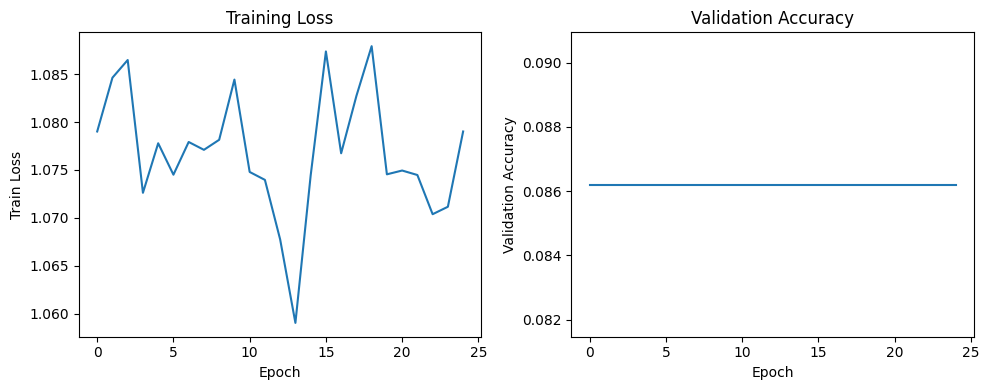

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(train_losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss")
ax1.set_title("Training Loss")
ax2.plot(val_accs)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy")
ax2.set_title("Validation Accuracy")
plt.tight_layout()
plt.show()

In [42]:
CLASS_NAMES = ["tech", "sports", "weather"]

def predict(text, model, vocab, max_len=10, device=device):
    model.eval()
    x = encode_text(text, vocab, max_len).unsqueeze(0).to(device)  # (1, max_len)
    with torch.no_grad():
        logits = model(x)
        pred_idx = logits.argmax(dim=1).item()
    return pred_idx, CLASS_NAMES[pred_idx]

# Example predictions
for sent in ["python programming is fun", "football match tomorrow", "rain and storm"]:
    idx, name = predict(sent, model_tc, vocab)
    print(f"'{sent}' -> {name} (class {idx})")

'python programming is fun' -> tech (class 0)
'football match tomorrow' -> tech (class 0)
'rain and storm' -> weather (class 2)


In [36]:
# Save model and vocab
model_path = "text_classifier_model.pt"
vocab_path = "text_classifier_vocab.pt"
torch.save(model_tc.state_dict(), model_path)
torch.save({"vocab": vocab, "max_len": 10, "num_classes": 3, "embed_dim": 32, "hidden_dim": 64}, vocab_path)
print("Saved model to", model_path, "and vocab/config to", vocab_path)

Saved model to text_classifier_model.pt and vocab/config to text_classifier_vocab.pt


In [37]:
# Load and run inference again
ckpt = torch.load(vocab_path, map_location=device)
loaded_vocab = ckpt["vocab"]
loaded_max_len = ckpt["max_len"]
loaded_num_classes = ckpt["num_classes"]

model_loaded_tc = TextClassifier(
    vocab_size=len(loaded_vocab),
    embed_dim=ckpt["embed_dim"],
    hidden_dim=ckpt["hidden_dim"],
    num_classes=loaded_num_classes
).to(device)
model_loaded_tc.load_state_dict(torch.load(model_path, map_location=device))
model_loaded_tc.eval()

idx, name = predict("sunny weather today", model_loaded_tc, loaded_vocab, max_len=loaded_max_len)
print("Loaded model prediction for 'sunny weather today':", name)

Loaded model prediction for 'sunny weather today': weather


## Summary

In this notebook we covered:

1. **Tensors** — Creation, attributes (shape, dtype, device), operations, reshaping, indexing, NumPy interop, and moving tensors to GPU.
2. **Autograd** — `requires_grad`, `.backward()`, gradients, computation graph, `torch.no_grad()`, `.detach()`, and gradient zeroing.
3. **Model building** — `nn.Module`, core layers (Linear, ReLU, etc.), custom networks, `nn.Sequential`, loss functions, and optimizers.
4. **Training loops** — Forward, loss, backward, optimizer step, zero_grad; Dataset and DataLoader; validation with `model.eval()` and `torch.no_grad()`; saving and loading state dicts.
5. **Text classification** — Inline data, vocabulary, encoding, embedding + average pooling + classifier, full training, inference, and saving/loading model and vocab.

## Next Steps

- **CNNs and RNNs**: Explore `nn.Conv2d`, `nn.LSTM`, `nn.GRU` for vision and sequence tasks.
- **torchvision / torchtext**: Use built-in datasets and transforms for images and text.
- **Transfer learning**: Load pretrained models and fine-tune on your data.
- **Hugging Face**: Combine PyTorch with the Transformers library for modern NLP (BERT, GPT, etc.).